In [1]:
##############################################################################
# IMPORTAÇÃO DAS BIBLIOTECAS
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
##############################################################################
# CONFIGURAÇÕES VISUAIS
##############################################################################

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
##############################################################################
# CARREGAMENTO DOS DADOS
##############################################################################

df = pd.read_csv("../data/SampleSuperstore.csv", encoding="latin-1") # Carregar o dataset do Superstore a partir do arquivo CSV, utilizando a codificação "latin-1" para evitar problemas com caracteres acentuados

In [4]:
##############################################################################
# VISUALIZAÇÃO INICIAL DOS DADOS
##############################################################################

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# EXPLORAÇÃO INICIAL DOS DADOS

In [5]:
df.shape # Verificar o número de linhas e colunas do DataFrame

(9994, 21)

In [6]:
for coluna in df.columns: # Iterar sobre as colunas do DataFrame e imprimir o nome de cada coluna
    print(coluna)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [8]:
################################################################################
# ESTATISTICAS DESCRITIVAS
################################################################################

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
################################################################################
# VERIFICAÇÃO DE VALORES NULOS
################################################################################

df.isnull().sum()
(df.isnull().sum() / len(df)) * 100

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

In [10]:
################################################################################
# VERIFICAR DUPLICATAS
################################################################################

df.duplicated().sum()

np.int64(0)

In [11]:
##############################################################################
# TRATAMENTO E PREPARAÇÃO DOS DADOS
##############################################################################

df = df.drop_duplicates() # Remover duplicatas, se existirem
df.duplicated().sum() # Verificar novamente para garantir que as duplicatas foram removidas

df.info() # Verificar o tipo de dados e se há valores nulos após o tratamento

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [12]:
################################################################################
# PADRONIZAÇÃO DE DADOS
################################################################################

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_") # Padronizar os nomes das colunas
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

df.info() # Verificar o tipo de dados após a conversão

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub-category   9994 non-null   s

In [14]:
##############################################################################
# KPIs PRINCIPAIS
##############################################################################

# KPIs são indicadores-chave de desempenho que ajudam a medir o sucesso do negócio. No contexto do Superstore, alguns KPIs importantes podem incluir:

print(f"Total de vendas: {df['sales'].sum():,.2f}")

print(f"Lucro total: {df['profit'].sum():,.2f}")

print(f"Quantidade de pedidos: {df['order_id'].nunique()}")

print(f"Quantidade de clientes: {df['customer_id'].nunique()}")

Total de vendas: 2,297,200.86
Lucro total: 286,397.02
Quantidade de pedidos: 5009
Quantidade de clientes: 793


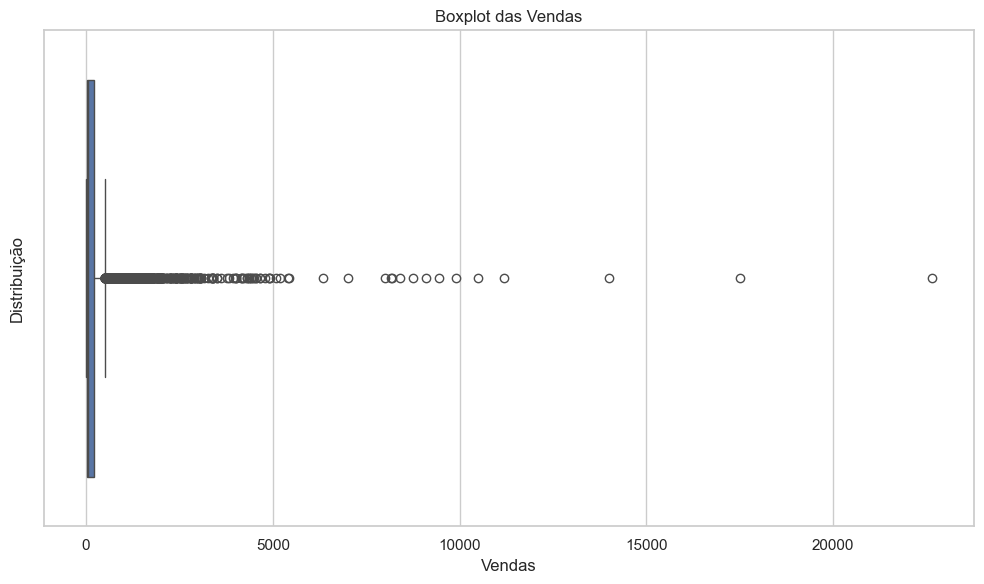

In [15]:
##################################################################################
# OUTLIERS
##################################################################################

sns.boxplot(x=df["sales"]) # Criar um boxplot para a coluna "sales"

plt.title("Boxplot das Vendas") # Adicionar título ao gráfico
plt.xlabel("Vendas") # Adicionar rótulo ao eixo x
plt.ylabel("Distribuição") # Adicionar rótulo ao eixo y

plt.tight_layout()

plt.savefig("../images/boxplot_sales.png") # Salvar o gráfico como uma imagem PNG

plt.show() # Exibir o gráfico

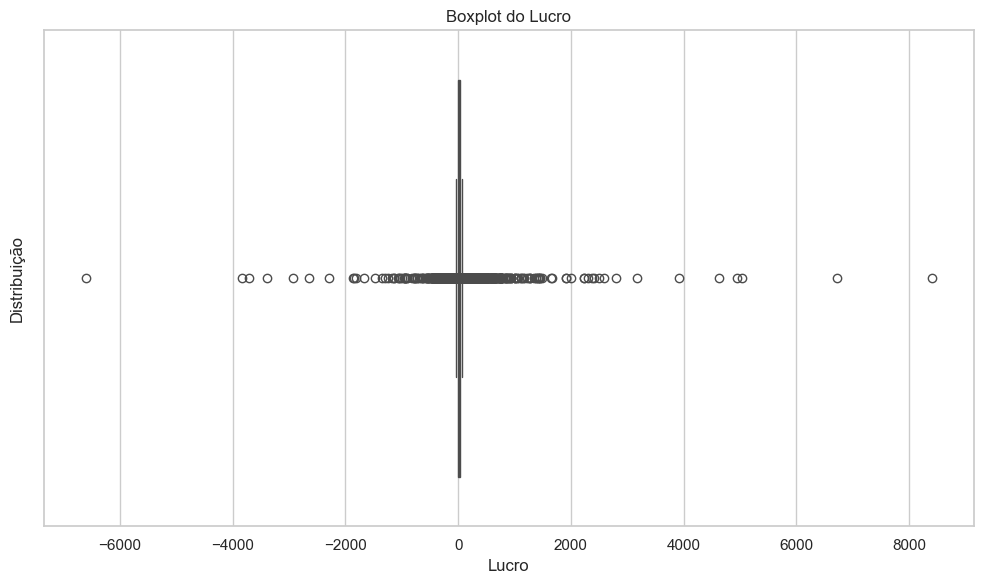

In [16]:
################################################################################
# LUCRO
################################################################################

sns.boxplot(x=df["profit"])
plt.title("Boxplot do Lucro")
plt.xlabel("Lucro")
plt.ylabel("Distribuição")

plt.tight_layout()

plt.savefig("../images/boxplot_profit.png")

plt.show()


# ANÁLISE EXPLORATÓRIA DE DADOS (AED)


In [17]:
##############################################################################
# VENDAS TOTAIS
##############################################################################

total_vendas = df["sales"].sum()
print(f"Vendas Totais: ${total_vendas:.2f}")

Vendas Totais: $2297200.86


In [18]:
##############################################################################
# LUCRO TOTAL
##############################################################################

total_lucro = df["profit"].sum()
print(f"Lucro Total: ${total_lucro:.2f}")

Lucro Total: $286397.02


In [19]:
############################################################################
# VENDAS POR CATEGORIA
############################################################################

vendas_por_categoria = df.groupby("category")["sales"].sum()
vendas_por_categoria

category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64

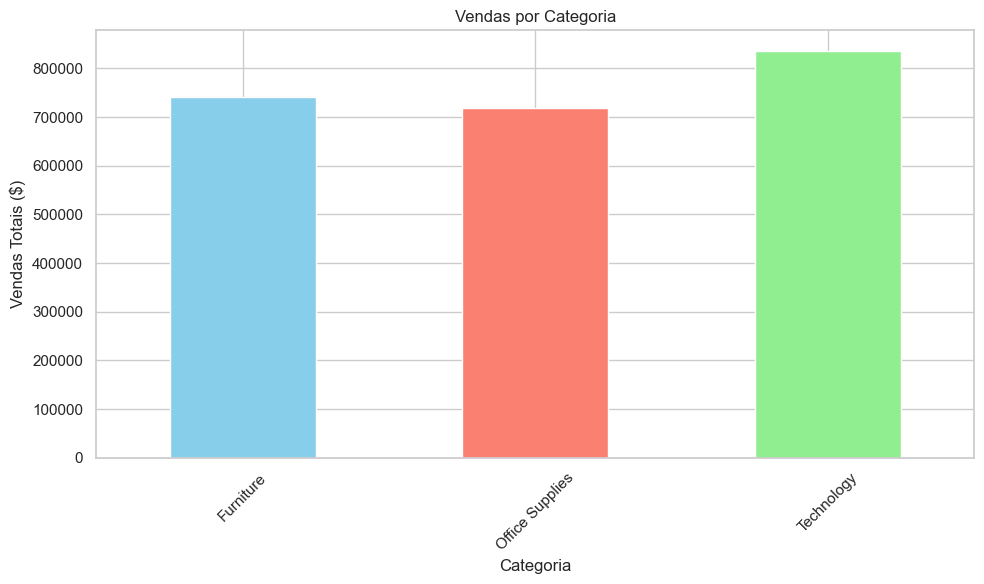

In [20]:
# GRÁFICO DE VENDAS POR SEGMENTO

vendas_por_categoria.plot(kind="bar", color=["skyblue", "salmon", "lightgreen"])
plt.title("Vendas por Categoria") # Adicionar título ao gráfico
plt.xlabel("Categoria") # Adicionar rótulo ao eixo x
plt.ylabel("Vendas Totais ($)") # Adicionar rótulo ao eixo y
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo x para melhor visualização

plt.tight_layout() # Ajustar layout para evitar sobreposição

plt.savefig("../images/vendas_por_categoria.png")

plt.show() # Exibir o gráfico

In [21]:
##############################################################################
# LUCRO POR CATEGORIA
##############################################################################

lucro_por_categoria = df.groupby("category")["profit"].sum()
lucro_por_categoria

category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: profit, dtype: float64

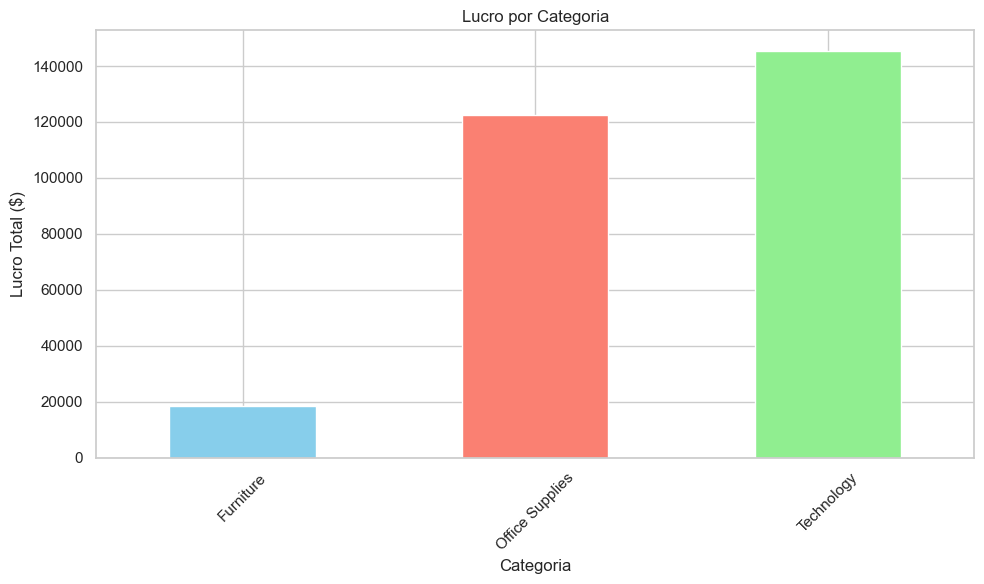

In [22]:
# GRAFO DE LUCRO POR CATEGORIA

lucro_por_categoria.plot(kind="bar", color=["skyblue", "salmon", "lightgreen"])
plt.title("Lucro por Categoria") # Adicionar título ao gráfico
plt.xlabel("Categoria") # Adicionar rótulo ao eixo x
plt.ylabel("Lucro Total ($)") # Adicionar rótulo ao eixo y
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo x para melhor visualização

plt.tight_layout() # Ajustar layout para evitar sobreposição

plt.savefig("../images/lucro_por_categoria.png")

plt.show() # Exibir o gráfico

In [23]:
##############################################################################
# VENDAS POR SEGMENTO
##############################################################################

vendas_por_segmento = df.groupby("segment")["sales"].sum()
vendas_por_segmento

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

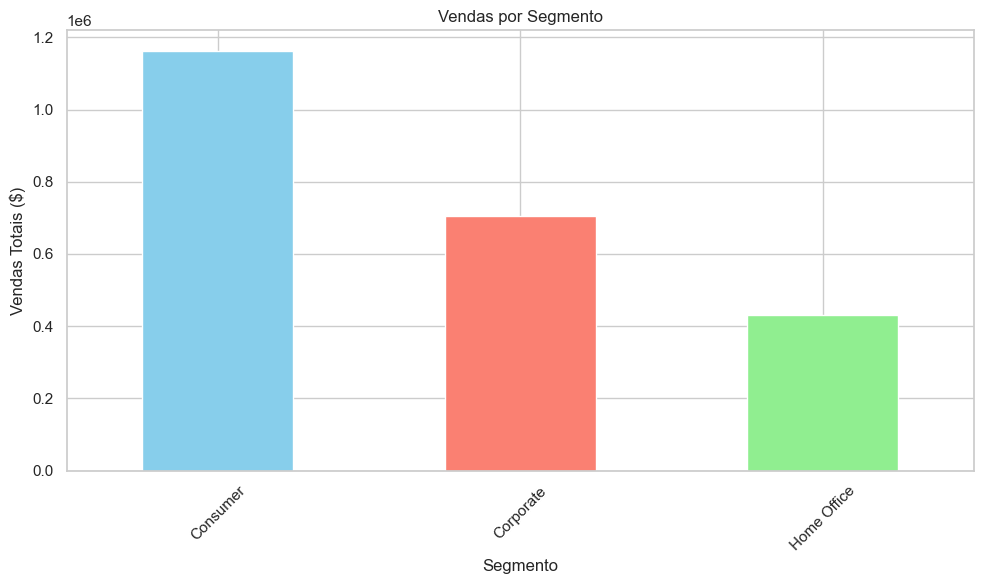

In [24]:
# GRAFO DE VENDAS POR SEGMENTO

vendas_por_segmento.plot(kind="bar", color=["skyblue", "salmon", "lightgreen"])
plt.title("Vendas por Segmento") # Adicionar título ao gráfico
plt.xlabel("Segmento") # Adicionar rótulo ao eixo x
plt.ylabel("Vendas Totais ($)") # Adicionar rótulo ao eixo y
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo x para melhor visualização

plt.tight_layout() # Ajustar layout para evitar sobreposição

plt.savefig("../images/vendas_por_segmento.png")

plt.show() # Exibir o gráfico

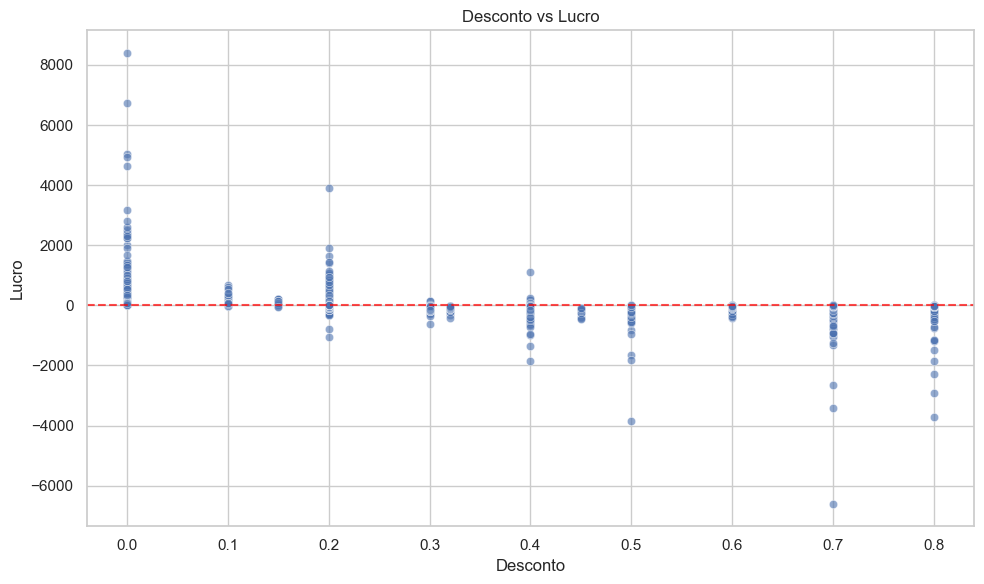

In [25]:
##############################################################################
# RELAÇÃO ENTRE VENDAS E LUCRO
##############################################################################

# Criar um gráfico de dispersão (scatter plot) para visualizar a relação entre vendas e lucro

sns.scatterplot(data=df, x="discount", y="profit", alpha=0.6) # Criar um scatter plot com desconto no eixo x e lucro no eixo y, ajustando a transparência dos pontos
plt.title("Desconto vs Lucro")
plt.xlabel("Desconto")
plt.ylabel("Lucro")
plt.axhline(y=0, color="red", linestyle="--", alpha=0.7) # Linha horizontal em y=0 para facilitar a leitura

plt.tight_layout()

plt.savefig("../images/desconto_vs_lucro.png")

plt.show()

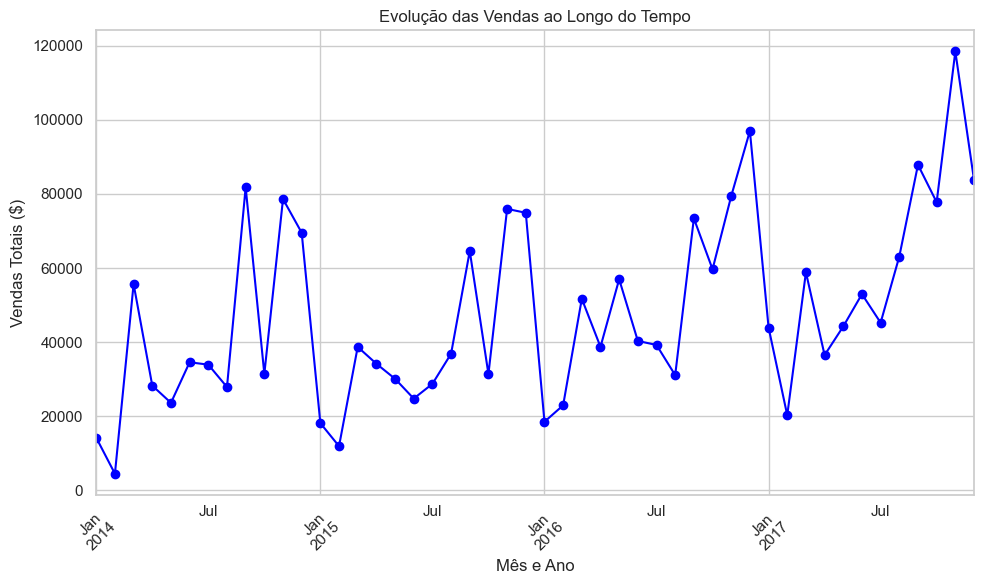

In [26]:
#############################################################################
# EVOLUÇÃO DAS VENDAS AO LONGO DO TEMPO
#############################################################################

df["month_year"] = df["order_date"].dt.to_period("M") # Criar uma nova coluna para mês e ano
vendas_mensais = df.groupby("month_year")["sales"].sum() # Agrupar por mês e ano e somar as vendas

vendas_mensais.plot(kind="line", marker="o", color="blue")
plt.title("Evolução das Vendas ao Longo do Tempo") # Adicionar título ao gráfico
plt.xlabel("Mês e Ano") # Adicionar rótulo ao eixo x
plt.ylabel("Vendas Totais ($)") # Adicionar rótulo ao eixo y
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo x para melhor visualização melhor visualização

plt.tight_layout()

plt.savefig("../images/evolucao_vendas.png")

plt.show() # Exibir o gráfico

In [27]:
##############################################################################
# CORRELAÇÃO ENTRE VARIÁVEIS
##############################################################################

correlacao = df[["sales", "profit", "discount", "quantity"]].corr() # Calcular a correlação entre vendas, lucro e desconto
correlacao

,sales,profit,discount,quantity
sales,1.000000,0.479064,-0.028190,0.200795
profit,0.479064,1.000000,-0.219487,0.066253
discount,-0.028190,-0.219487,1.000000,0.008623
quantity,0.200795,0.066253,0.008623,1.000000


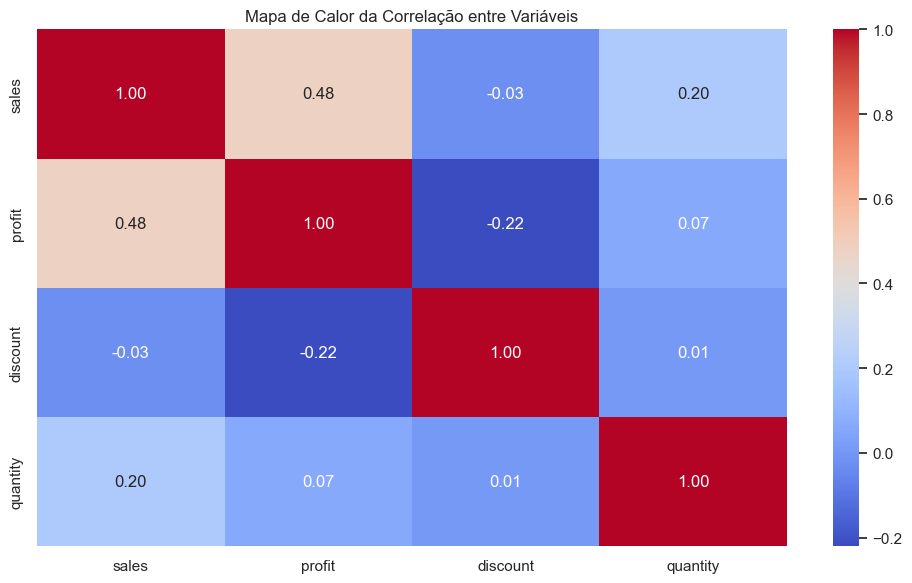

In [28]:
##############################################################################
# HEATMAP DE CORRELAÇÃO
##############################################################################
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f") # Criar um heatmap para visualizar a correlação entre as variáveis
plt.title("Mapa de Calor da Correlação entre Variáveis") # Adicionar título ao gráfico

plt.tight_layout()

plt.savefig("../images/correlacao_variaveis.png")

plt.show() # Exibir o gráfico

# INSIGHTS

### Insight 1 — Desempenho das Categorias

A categoria Technology apresentou o maior volume de vendas e também uma das maiores margens de lucro, indicando forte potencial de rentabilidade para o negócio.

Já determinadas categorias apresentaram menor lucratividade proporcional, sugerindo necessidade de revisão estratégica.

### Insight 2 — Impacto dos Descontos

A análise entre desconto e lucro demonstrou uma tendência negativa: conforme os descontos aumentam, o lucro tende a diminuir.

Esse comportamento sugere que políticas agressivas de desconto podem comprometer a rentabilidade da empresa.

### Insight 3 — Segmentação de Clientes

O segmento Consumer apresentou o maior volume de vendas, indicando forte participação no faturamento total da empresa.

Essa informação pode auxiliar na definição de campanhas e estratégias comerciais mais direcionadas.

### Insight 4 — Tendência Temporal

A análise temporal revelou períodos de crescimento nas vendas ao longo do tempo, permitindo identificar tendências e possíveis sazonalidades no comportamento comercial.

# Conclusão

O desenvolvimento deste projeto permitiu aplicar técnicas fundamentais de Análise Exploratória de Dados (AED) utilizando Python e bibliotecas voltadas para Data Science.

Durante a análise, foi possível identificar padrões relevantes relacionados às vendas, lucratividade, segmentos de clientes, categorias de produtos e impacto dos descontos sobre o desempenho financeiro da empresa.

Além disso, a construção das visualizações gráficas contribuiu para uma interpretação mais clara dos dados, auxiliando na geração de insights estratégicos e no entendimento do comportamento comercial da empresa.

O projeto também possibilitou a prática de etapas importantes do fluxo de Data Science, incluindo carregamento, tratamento, preparação, exploração e interpretação dos dados.